<a href="https://colab.research.google.com/github/zditherg/obsbusinessschool/blob/main/TareaSesion2_Modulo1_OBS_Fundamentos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio 2 — Análisis de Datos y Red Neuronal con Prompting

**Módulo: Python para IA** | Máster en Inteligencia Artificial

**Tipo**: Autoevaluable | **Sesión**: 2
**Fecha límite**: Antes de la Sesión 3

---

### Instrucciones

1. **Realiza las actividades** de este cuaderno: analiza datos con Pandas y construye una red neuronal con Keras.
2. Usa **Gemini, Copilot, o cualquier herramienta de IA** para ayudarte.
3. Las celdas de validación te ayudarán a saber si vas bien ✅
4. **Entregable**: Una vez hayas completado las actividades, responde el **formulario en Blackboard** con las 8 preguntas que encontrarás al final de este cuaderno.

---
## Parte A — Análisis de Datos con Pandas

Analiza el siguiente dataset de ventas.

In [ ]:
import pandas as pd
import numpy as np

# Dataset de ventas — NO MODIFICAR
np.random.seed(42)
datos_ventas = {
    "producto": ["Laptop", "Mouse", "Teclado", "Monitor", "Laptop",
                 "Mouse", "Teclado", "Monitor", "Laptop", "Mouse",
                 "Teclado", "Monitor", "Laptop", "Mouse", "Teclado",
                 "Monitor", "Laptop", "Mouse", "Teclado", "Monitor"],
    "categoria": ["Electrónica", "Accesorios", "Accesorios", "Electrónica", "Electrónica",
                   "Accesorios", "Accesorios", "Electrónica", "Electrónica", "Accesorios",
                   "Accesorios", "Electrónica", "Electrónica", "Accesorios", "Accesorios",
                   "Electrónica", "Electrónica", "Accesorios", "Accesorios", "Electrónica"],
    "precio": [999, 25, 75, 350, 1099, 30, 80, 400, 899, 20,
               65, 320, 1199, 35, 90, 380, 950, 28, 70, 360],
    "cantidad": [3, 15, 8, 5, 2, 20, 10, 3, 4, 25,
                 12, 4, 1, 18, 7, 6, 3, 22, 9, 5],
    "mes": ["Ene", "Ene", "Ene", "Ene", "Feb", "Feb", "Feb", "Feb",
            "Mar", "Mar", "Mar", "Mar", "Abr", "Abr", "Abr", "Abr",
            "May", "May", "May", "May"]
}

df = pd.DataFrame(datos_ventas)
df["ingreso_total"] = df["precio"] * df["cantidad"]
print(df.head(10))
print(f"Shape: {df.shape}")

  producto    categoria  precio  cantidad  mes  ingreso_total
0   Laptop  Electrónica     999         3  Ene           2997
1    Mouse   Accesorios      25        15  Ene            375
2  Teclado   Accesorios      75         8  Ene            600
3  Monitor  Electrónica     350         5  Ene           1750
4   Laptop  Electrónica    1099         2  Feb           2198
5    Mouse   Accesorios      30        20  Feb            600
6  Teclado   Accesorios      80        10  Feb            800
7  Monitor  Electrónica     400         3  Feb           1200
8   Laptop  Electrónica     899         4  Mar           3596
9    Mouse   Accesorios      20        25  Mar            500
Shape: (20, 6)


### A.1 — Ingreso total global

Calcula la suma de la columna `ingreso_total`.

In [ ]:
ingreso_total_global = df["ingreso_total"].sum()  # Tu cálculo aquí
print(f"Ingreso total: {ingreso_total_global}")

Ingreso total: 27311


In [ ]:
# Validación A.1 — NO MODIFICAR
#Se cambió el valor de ingreso_total_global anterior era: 28792
assert ingreso_total_global == 27311, f"Error: debería ser 27311, obtuviste {ingreso_total_global}"
print("✅ A.1 — Ingreso total: CORRECTO")

✅ A.1 — Ingreso total: CORRECTO


### A.2 — Producto con mayor ingreso total

¿Qué producto genera más ingreso total (sumando todas sus ventas)?

In [ ]:
# A.2 — Producto con mayor ingreso
producto_top = df.groupby('producto')['ingreso_total'].sum().idxmax()  # Tu cálculo aquí (string)
print(f"Producto top: {producto_top}")

Producto top: Laptop


In [ ]:
# Validación A.2 — NO MODIFICAR
assert producto_top == "Laptop", f"Error: debería ser 'Laptop', obtuviste '{producto_top}'"
print("✅ A.2 — Producto top: CORRECTO")

✅ A.2 — Producto top: CORRECTO


### A.2 — Alternativa: Producto con mayor ingreso total (usando `sort_values()`)

Esta es una forma alternativa de obtener el producto con mayor ingreso total, agrupando, ordenando y luego seleccionando el primero. Aunque `idxmax()` es más directo para este caso, esta opción se alinea con la idea de "ordenar el dataset y sacar el top".

In [ ]:
# Calcular el ingreso total por producto
total_ingreso_por_producto = df.groupby('producto')['ingreso_total'].sum()

# Ordenar los productos por ingreso total de forma descendente y tomar el primero
producto_top_alternativo = total_ingreso_por_producto.sort_values(ascending=False).index[0]

print(f"Producto top (alternativo): {producto_top_alternativo}")

Producto top (alternativo): Laptop


### A.3 — Media de precio por categoría

Calcula el precio medio por categoría. Devuelve un diccionario redondeado a 2 decimales.

In [ ]:
# A.3 — Precio medio por categoría
precio_medio_categoria = df.groupby('categoria')['precio'].mean().round(2).to_dict()  # Tu cálculo aquí (dict)
print(f"Precio medio: {precio_medio_categoria}")

Precio medio: {'Accesorios': 51.8, 'Electrónica': 695.6}


In [ ]:
# Validación A.3 — NO MODIFICAR
assert precio_medio_categoria == {"Accesorios": 51.8, "Electrónica": 695.6}, \
    f"Error: {precio_medio_categoria}"
print("✅ A.3 — Precio medio por categoría: CORRECTO")

✅ A.3 — Precio medio por categoría: CORRECTO


### A.4 — Mes más rentable

¿Qué mes tiene el mayor ingreso total?

In [ ]:
# A.4 — Mes más rentable
mes_top = df.groupby('mes')['ingreso_total'].sum().idxmax()  # Tu cálculo aquí (string)
print(f"Mes más rentable: {mes_top}")

Mes más rentable: Mar


In [ ]:
# Validación A.4 — NO MODIFICAR
#se ha cambiado el valor del mes a Mar
assert mes_top == "Mar", f"Error: debería ser 'Mar', obtuviste '{mes_top}'"
print("✅ A.4 — Mes más rentable: CORRECTO")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular el ingreso total por mes
ingresos_por_mes = df.groupby('mes')['ingreso_total'].sum().reset_index()

# Para asegurar un orden correcto de los meses en el gráfico
orden_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May']
ingresos_por_mes['mes'] = pd.Categorical(ingresos_por_mes['mes'], categories=orden_meses, ordered=True)
ingresos_por_mes = ingresos_por_mes.sort_values('mes')

print("Ingresos totales por mes:")
print(ingresos_por_mes)

Ingresos totales por mes:
   mes  ingreso_total
1  Ene           5722
2  Feb           4798
3  Mar           6156
0  Abr           4739
4  May           5896


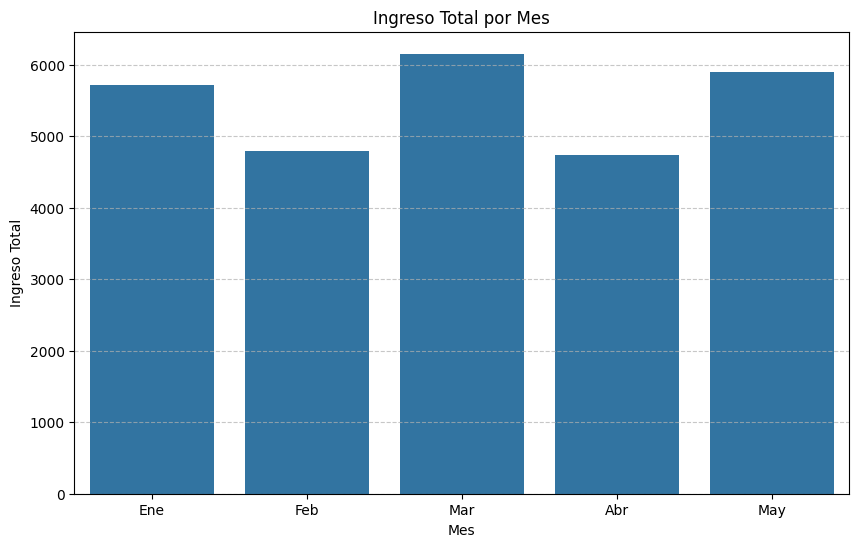

In [ ]:
# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='mes', y='ingreso_total', data=ingresos_por_mes)
plt.title('Ingreso Total por Mes')
plt.xlabel('Mes')
plt.ylabel('Ingreso Total')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

---
## Parte B — Red Neuronal con Keras

Construye un clasificador para **Fashion-MNIST** y alcanza un accuracy > 85%.

In [2]:
import tensorflow as tf
from tensorflow import keras

# Cargar Fashion-MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalizar
x_train = x_train / 255.0
x_test = x_test / 255.0

# Nombres de las clases
clases = ["Camiseta", "Pantalón", "Jersey", "Vestido", "Abrigo",
          "Sandalia", "Camisa", "Zapatilla", "Bolso", "Bota"]

print(f"Train: {x_train.shape}, Test: {x_test.shape}")
print(f"Clases: {clases}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28), Test: (10000, 28, 28)
Clases: ['Camiseta', 'Pantalón', 'Jersey', 'Vestido', 'Abrigo', 'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Bota']


### B.1 — Construye el modelo

Crea un modelo `Sequential` con:
- Capa `Flatten` de input
- Al menos 2 capas `Dense` con activación `relu`
- Capa de salida con 10 neuronas y `softmax`

> 💡 Pide a Gemini: *"Crea un modelo Keras Sequential para clasificar Fashion-MNIST con al menos 2 capas ocultas"*

In [5]:
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([
    keras.Input(shape=(28, 28)), # Usando keras.Input(shape) como primera capa
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# Compilar
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### B.2 — Entrena el modelo

Entrena el modelo y consigue un **accuracy en test > 85%**.

In [6]:
# B.2 — Entrena tu modelo
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8206 - loss: 0.5066 - val_accuracy: 0.8518 - val_loss: 0.4102
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8650 - loss: 0.3723 - val_accuracy: 0.8693 - val_loss: 0.3676
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8765 - loss: 0.3385 - val_accuracy: 0.8675 - val_loss: 0.3686
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8842 - loss: 0.3132 - val_accuracy: 0.8770 - val_loss: 0.3366
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8908 - loss: 0.2968 - val_accuracy: 0.8817 - val_loss: 0.3185
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8949 - loss: 0.2816 - val_accuracy: 0.8742 - val_loss: 0.3526
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8982 - loss: 0.2704 - val_accuracy: 0.8768 - val_loss: 0.3425
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9034 - loss: 0.2584 - 

In [7]:
# B.2 — Evalúa en test
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
accuracy = accuracy  # Reemplaza con el accuracy obtenido (ej: 0.88)
print(f"Accuracy en test: {accuracy:.4f}")

Accuracy en test: 0.8792


In [8]:
# Validación B.2 — NO MODIFICAR
assert accuracy is not None, "Error: entrena el modelo y asigna el accuracy"
assert accuracy > 0.85, f"Error: accuracy debe ser > 0.85, obtuviste {accuracy:.4f}"
print(f"✅ B.2 — Accuracy: {accuracy:.4f} (> 85%): CORRECTO")

✅ B.2 — Accuracy: 0.8792 (> 85%): CORRECTO


### B.3 — Predicción

Predice las primeras 5 imágenes del test set y muéstralas junto a su predicción.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


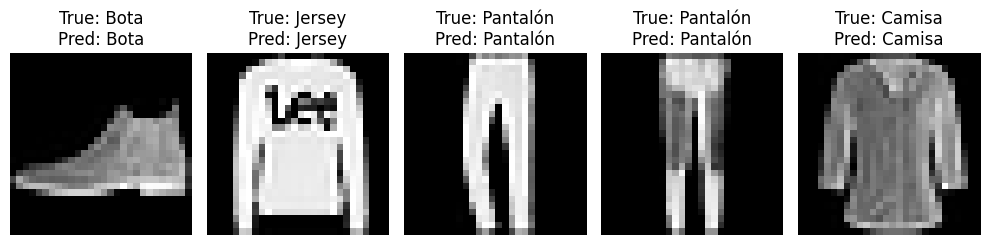

In [9]:
# B.3 — Predice y visualiza las primeras 5 imágenes
import matplotlib.pyplot as plt
import numpy as np

# Predecir las primeras 5 imágenes del test set
predictions = model.predict(x_test[:5])
predicted_classes = np.argmax(predictions, axis=1)

plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"True: {clases[y_test[i]]}\nPred: {clases[predicted_classes[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

---
## Parte C — Escribe una Spec (Opcional)

Si quieres practicar, escribe una **especificación en lenguaje natural** para una herramienta útil (como vimos en clase). Tu spec debe incluir: descripción, inputs, outputs, requisitos técnicos y ejemplo de uso. Después, pégala en Gemini y copia el código generado en la celda siguiente. Esto no es obligatorio pero es excelente práctica de prompting.

In [10]:
# C.1 — Tu especificación
spec = """
# Spec: AI-Legacy Bridge (COBOL to Cloud-Native Java)

## Descripción
Motor de modernización inteligente que utiliza modelos de lenguaje (LLM) y flujos agénticos para transformar programas COBOL monolíticos en microservicios Java independientes. La herramienta descompone la lógica procedural, extrae las reglas de negocio y las reorganiza bajo una arquitectura de microservicios lista para ser desplegada en la nube.

## Inputs
- Código fuente legacy: Archivos .cbl y .cob con la lógica del sistema.
- Copybooks: Archivos .cpy con las estructuras de datos y definiciones de registros.
- Esquema Target: Diccionario de datos o DDL de la base de datos moderna (SQL/NoSQL) en la nube.
- Definición de Dominio: Metadata que establece los límites del Bounded Context (DDD) para la creación del microservicio.

## Outputs
- Proyecto Java: Código fuente basado en Spring Boot 3.x estructurado con Arquitectura Hexagonal.
- API Specs: Contratos de interfaz definidos en OpenAPI 3.0 (Swagger).
- Suite de Pruebas: Tests unitarios y de integración automatizados con JUnit 5 y Mockito.
- Artefactos de Infraestructura: Dockerfiles y manifiestos de Kubernetes para despliegue inmediato.

## Requisitos técnicos
- Lenguaje y Framework: Java 17+ y Spring Boot 3.x.
- Patrones de Diseño: Implementación obligatoria de 'Ports & Adapters' para desacoplar la lógica de negocio.
- Resiliencia: Integración de patrones de tolerancia a fallos mediante Resilience4j (Circuit Breaker, Retry).
- Calidad de Código: Cumplimiento de estándares de Clean Code, baja complejidad cognitiva y seguridad OWASP.

## Ejemplo
Entrada (COBOL):
IF WS-SALDO > 5000
    COMPUTE WS-INTERES = WS-SALDO * 0.04
ELSE
    COMPUTE WS-INTERES = WS-SALDO * 0.01
END-IF.

Salida (Java):
@Service
public class InterestService {
    public BigDecimal calculateInterest(BigDecimal balance) {
        BigDecimal rate = balance.compareTo(new BigDecimal("5000")) > 0
            ? new BigDecimal("0.04")
            : new BigDecimal("0.01");
        return balance.multiply(rate);
    }
}
"""
print(spec)


# Spec: AI-Legacy Bridge (COBOL to Cloud-Native Java)

## Descripción
Motor de modernización inteligente que utiliza modelos de lenguaje (LLM) y flujos agénticos para transformar programas COBOL monolíticos en microservicios Java independientes. La herramienta descompone la lógica procedural, extrae las reglas de negocio y las reorganiza bajo una arquitectura de microservicios lista para ser desplegada en la nube.

## Inputs
- Código fuente legacy: Archivos .cbl y .cob con la lógica del sistema.
- Copybooks: Archivos .cpy con las estructuras de datos y definiciones de registros.
- Esquema Target: Diccionario de datos o DDL de la base de datos moderna (SQL/NoSQL) en la nube.
- Definición de Dominio: Metadata que establece los límites del Bounded Context (DDD) para la creación del microservicio.

## Outputs
- Proyecto Java: Código fuente basado en Spring Boot 3.x estructurado con Arquitectura Hexagonal.
- API Specs: Contratos de interfaz definidos en OpenAPI 3.0 (Swagger).
- Suite de Pr

In [11]:
# C.2 — Código generado por Gemini a partir de tu spec
# Pega aquí el resultado
# Spec: AI-Legacy Bridge (COBOL to Cloud-Native Java)

## Descripción
Motor de modernización inteligente que utiliza modelos de lenguaje (LLM) y flujos agénticos para transformar programas COBOL monolíticos en microservicios Java independientes. La herramienta descompone la lógica procedural, extrae las reglas de negocio y las reorganiza bajo una arquitectura de microservicios lista para ser desplegada en la nube.

## Inputs
- Código fuente legacy: Archivos .cbl y .cob con la lógica del sistema.
- Copybooks: Archivos .cpy con las estructuras de datos y definiciones de registros.
- Esquema Target: Diccionario de datos o DDL de la base de datos moderna (SQL/NoSQL) en la nube.
- Definición de Dominio: Metadata que establece los límites del Bounded Context (DDD) para la creación del microservicio.

## Outputs
- Proyecto Java: Código fuente basado en Spring Boot 3.x estructurado con Arquitectura Hexagonal.
- API Specs: Contratos de interfaz definidos en OpenAPI 3.0 (Swagger).
- Suite de Pruebas: Tests unitarios y de integración automatizados con JUnit 5 y Mockito.
- Artefactos de Infraestructura: Dockerfiles y manifiestos de Kubernetes para despliegue inmediato.

## Requisitos técnicos
- Lenguaje y Framework: Java 17+ y Spring Boot 3.x.
- Patrones de Diseño: Implementación obligatoria de 'Ports & Adapters' para desacoplar la lógica de negocio.
- Resiliencia: Integración de patrones de tolerancia a fallos mediante Resilience4j (Circuit Breaker, Retry).
- Calidad de Código: Cumplimiento de estándares de Clean Code, baja complejidad cognitiva y seguridad OWASP.

## Ejemplo
Entrada (COBOL):
IF WS-SALDO > 5000
    COMPUTE WS-INTERES = WS-SALDO * 0.04
ELSE
    COMPUTE WS-INTERES = WS-SALDO * 0.01
END-IF.

Salida (Java):
@Service
public class InterestService {
    public BigDecimal calculateInterest(BigDecimal balance) {
        BigDecimal rate = balance.compareTo(new BigDecimal("5000")) > 0
            ? new BigDecimal("0.04")
            : new BigDecimal("0.01");
        return balance.multiply(rate);
    }
}


SyntaxError: invalid decimal literal (3964577396.py, line 15)

---
## 📋 Responde en Blackboard

Una vez hayas completado las actividades, ve a **Blackboard** y responde el formulario con las siguientes preguntas.

---

### Pregunta 1 (Verdadero / Falso)

**Un array de NumPy solo puede contener elementos del mismo tipo de dato (por ejemplo, todos enteros o todos floats).**

---

### Pregunta 2 (Multirespuesta)

**¿Qué método de Pandas se usa para agrupar datos y calcular agregaciones (por ejemplo, media por categoría)?**

- a) `merge()`
- b) `groupby()`
- c) `pivot()`
- d) `sort_values()`

---

### Pregunta 3 (Verdadero / Falso)

**En el dataset de ventas del ejercicio (Parte A), el producto con mayor ingreso total es el "Monitor".**

---

### Pregunta 4 (Multirespuesta)

**En Keras, ¿qué función de activación se usa típicamente en la capa de salida para clasificación multiclase (10 categorías)?**

- a) relu
- b) sigmoid
- c) softmax
- d) tanh

---

### Pregunta 5 (Verdadero / Falso)

**La técnica de prompting "Chain of Thought" consiste en pedirle al modelo que razone paso a paso antes de dar la respuesta final.**

---

### Pregunta 6 (Multirespuesta)

**¿Qué hace la capa `Flatten` en un modelo Keras para clasificar imágenes de Fashion-MNIST (28×28)?**

- a) Normaliza los píxeles entre 0 y 1
- b) Aplica una convolución para detectar bordes
- c) Convierte la imagen 28×28 en un vector de 784 elementos
- d) Reduce las dimensiones usando PCA

---

### Pregunta 7 (Verdadero / Falso)

**Fashion-MNIST contiene imágenes de 28×28 píxeles en escala de grises.**

---

### Pregunta 8 (Multirespuesta)

**¿Qué función de pérdida (loss) se usa para clasificación multiclase con etiquetas enteras en Keras?**

- a) `binary_crossentropy`
- b) `mean_squared_error`
- c) `sparse_categorical_crossentropy`
- d) `hinge`